# PartUV × Texel Density 测试 notebook

**环境**：conda `geomae`（已装 `partuv` v0.1.2 + h5py/boto3/loguru/lightning）。
**数据**：`code/data/`（PartUV 官方 demo mesh ×4 + 带纹理 objaverse glb ×2）。
**做什么**：
1. 跑通官方 PartUV 管线（PartField 部件树 → C++ 递归展开）；
2. 用**面质心匹配**建立 chart ↔ 输入 mesh 的全局面对应（07 文档验证过：零误差、100% 覆盖）；
3. 统计未打包输出的 chart 尺度离散度（TD 不受控的实测证据）；
4. **密度层 mini-demo（L1 均匀 TD）**：按 3D 面积重缩放每个 chart + 简易 shelf packing，
   对比前后 per-face TD 的变异系数；
5. **纹理密度在物体表面上的体现（3D 热力图）**：物体**原始 UV** 的 TD 分布 →
   re-UV-map（PartUV + L1 密度层）之后的均匀分布（红=密度高/过采样，蓝=密度低/欠采样）。

> 换测试网格：改 CONFIG 里的 `MESH` 即可。输出存到 `outputs/<mesh名>/`。
> 注意：官方 demo 的 4 个 OBJ 不带 UV（"before"面板会自动跳过）；
> 两个 objaverse GLB 带原始 UV + 纹理，能看到完整的 before → after 故事。

---
**⚠ 与论文展示图对比时的三点说明**（以手雷 `f45ac2100d...obj` 为例，2026-07-13 实测）：
1. 本 notebook 的 "Raw non-packed" 面板**故意**把每个 chart 摆进等大网格（展示"chart 间尺度未定义"），
   不是最终图集；论文 teaser 那张是 **UVPackmaster 打包后的成品图**。要对比的话看 L1 面板
   （但它用的是我们的简易 shelf packing，不是 UVPackmaster）。
2. **chart 数不同是系统性差异，不是 bug**：本机跑 3 次全部稳定为 35 charts（论文图标注 26）。
   35 里有 15 个是 ≤4 面的小碎片 chart（9 个单面）——去掉碎片后 20 个大 chart，
   结构与论文图对应。差异来自公开代码/PartField 公开权重与论文实验版本不完全一致，
   论文数字本就不保证位级复现。
3. 这些小碎片 chart 对打包/padding 是真实负担——正好是密度/打包层可以顺手优化的点
   （cull、合并或 per-part 分组打包）。


## 术语澄清：只有一种"密度"

全篇只有一个物理量——**纹理密度 $\mathrm{TD}(f)$**（每单位表面积分到的纹素数）。
**L1 / L2 / L3 不是三种密度，是同一个密度的三种分配政策**（课题内部速记，出处：`纹理密度/01-研究任务梳理.md`）：

| 记号 | 含义 | 世界地图类比 | 结果 |
|---|---|---|---|
| L1 均匀 | 处处一样（业界标准/验收底线） | 自然地理等积地图 | $\mathrm{TD}\approx$ 常数 |
| L2 内容感知 | 细节多处多给（研究主攻） | 人口 cartogram | $\mathrm{TD}\propto$ 内容权重 |
| L3 用户指定 | 美术按 part 填预算（交互接口） | 行政规划 | $\mathrm{TD}$ 由预算决定 |

递进关系：L2 中 $\gamma=0$ 即退化为 L1；L3 = 把 L2 的自动权重换成人填的数。
另外三个易混名词都**不是**密度：`cw(f)` 是需求信号、`scale` 是 chart 级的密度汇总、
CV/CV$_w$ 是均匀度的评价指标。

---

## 纹理密度公式速查（与代码变量一一对应）

**1. 逐面纹理密度 TD** —— 代码 `face_td()` / `td_l1` / `td_before`

对三角形 $f$（3D 顶点 $v_0,v_1,v_2$，UV 顶点 $u_0,u_1,u_2$）：

$$A_{3D}(f)=\tfrac12\big\lVert(v_1-v_0)\times(v_2-v_0)\big\rVert,\qquad
A_{UV}(f)=\tfrac12\big\lvert(u_1-u_0)\times(u_2-u_0)\big\rvert$$

$$\mathrm{TD}(f)=R\cdot\sqrt{\frac{A_{UV}(f)}{A_{3D}(f)}}\qquad\text{（单位: px / 世界长度单位）}$$

$R$ 为图集分辨率（如 1024）。**开根号**是因为密度是线性量（px/cm），而面积是二次量。
本 notebook 的图表多用相对 TD（省略 $R$，只看分布形状）。

**2. chart 线性尺度** —— 代码 `charts[i]["scale"]`

$$s_c=\sqrt{\frac{\sum_{f\in c}A_{UV}(f)}{\sum_{f\in c}A_{3D}(f)}}$$

PartUV 的失真界 $\tau$ 保证 chart 内部 $\mathrm{TD}(f)\approx s_c$（波动 $\lesssim\pm25\%$），
所以**控制整模型的密度分布 = 给每个 chart 定一个标量**。

**3. L1 均匀密度（uniform TD）** —— 布局目标 $A_{UV}\propto A_{3D}$

$$u'=u\cdot f_c,\qquad f_c=\sqrt{\frac{\sum_{f\in c}A_{3D}(f)}{\sum_{f\in c}A_{UV}(f)}}$$

缩放后所有 chart 共享同一 UV/3D 面积比，交给打包器（Blender `pack_islands`）
旋转/摆放/统一全局缩放——打包不改变相对尺度，密度分配原样保留。

**4. L2 内容感知密度** —— 代码 `w` / `demand`（GAMMA、ALPHA、W_CAP）

$$\widehat{cw}(f)=\frac{cw(f)}{\operatorname{median}\,cw},\qquad
w(f)=\min\Big(\big(1+\alpha\,\widehat{cw}(f)\big)^{\gamma},\,W_{\max}\Big)$$

$$D_c=\sum_{f\in c}A_{3D}(f)\,w(f),\qquad f_c=\sqrt{\frac{D_c}{\sum_{f\in c}A_{UV}(f)}}$$

$\gamma=0$ 退化为 L1。内容权重 $cw(f)$ 本 notebook 用**原纹理 oracle**
（面内 24 个重心采样点的亮度标准差）；生产中可替换为几何曲率、语义先验或两遍法实测。

**5. 均匀度指标** —— 代码 `cv` / `cvw`

$$\mathrm{CV}=\frac{\sigma(\mathrm{TD})}{\mu(\mathrm{TD})},\qquad
\mathrm{CV}_w=\frac{1}{\mu_w}\sqrt{\frac{\sum_f A_{3D}(f)\,\big(\mathrm{TD}(f)-\mu_w\big)^2}{\sum_f A_{3D}(f)}}$$

**以面积加权的 $\mathrm{CV}_w$ 为主指标**——未加权 CV 会被大量微小三角形抬高
（案例：某网格逐面 CV=2.18 而 $\mathrm{CV}_w$=0.078，感知上其实均匀）。

**6. PartUV 的失真度量**（论文式 (3)(4)）—— 代码 `c.distortion`

$$\mathrm{stretch}(f)=\frac{A_{UV}(f)/A_{3D}(f)}{\sum_{f'\in c}A_{UV}(f')\,/\sum_{f'\in c}A_{3D}(f')},\qquad
\mathrm{dist}(c)=\frac{1}{|c|}\sum_{f\in c}\max\big(\mathrm{stretch}(f),\,\mathrm{stretch}(f)^{-1}\big)\;\le\;\tau$$

即"单面的面积比相对 chart 整体面积比的偏离"——这正是第 2 条里 chart 内 TD 近似恒定的依据
（注意实测个别 chart 会略超 $\tau$，见 07 文档附录）。

**7. 绝对密度锚定（px/cm → 推荐分辨率）**

$$R_{\text{need}}=R\cdot\frac{\mathrm{TD}_{\text{target}}}{\overline{\mathrm{TD}}_{@R}}\;\longrightarrow\;\text{取最近的 }2^n$$

⚠ `preprocess()` 会把 mesh 归一化（中心化+等比缩放），换算真实 px/cm 时必须乘回世界尺度。


In [1]:
# ============ CONFIG ============
import os, glob

ROOT      = "/root/youjiaZhang/PartUV/code"
DATA      = f"{ROOT}/data"
OUT_ROOT  = f"{ROOT}/notebook/outputs"
CKPT      = "/root/zhaotianhao/PartField/model/model_objaverse.ckpt"   # PartField 权重(本地已有)
CFG_YAML  = f"{ROOT}/notebook/partuv_config.yaml"                      # 官方默认 config
THRESHOLD = 1.25                                                       # 失真阈值 τ

print("可用测试网格:")
for p in sorted(glob.glob(f"{DATA}/*")):
    print("  ", os.path.basename(p))

# ---- 选择测试网格(改这一行) ----
# MESH = f"{DATA}/objaverse_92ff65712c62408d.glb"   # 车轮: 带纹理+原始UV, heatmap/rebake/L2 演示最佳
# MESH = f"{DATA}/objaverse_7b323200b39349a1.glb"    # 带纹理; 原始逐面CV高但面积加权其实均匀(指标陷阱案例)
# MESH = f"{DATA}/objaverse_1389004d1eb94507.glb"    # 带纹理; 会触发管线丢面(已优雅处理, 灰色显示)
MESH = "/root/youjiaZhang/PartUV/code/PartUV/demo/meshes/f45ac2100d2342fa8ab39d38d0f874ba.obj"  # 论文手雷(无UV/无纹理: before/rebake/L2 自动跳过)

# 其它可选:
#   objaverse_7b323200b39349a1.glb  原始 TD CV≈2.18 (更极端)
#   objaverse_411c990e22ec42b2.glb  原始 TD CV≈0.08 (原始 UV 本来就均匀的反例)
#   0c3ca2b32545416f8f1e6f0e87def1a6.obj  PartUV 官方 demo(无 UV, before 面板自动跳过)
assert os.path.exists(MESH) and os.path.exists(CKPT) and os.path.exists(CFG_YAML)

可用测试网格:
   00000103_52f7124261ae4c558f800775_trimesh_000.obj
   0c3ca2b32545416f8f1e6f0e87def1a6.obj
   f45ac2100d2342fa8ab39d38d0f874ba.obj
   objaverse_1389004d1eb94507.glb
   objaverse_411c990e22ec42b2.glb
   objaverse_7b323200b39349a1.glb
   objaverse_92ff65712c62408d.glb
   table.obj


In [2]:
# ============ 加载 PartField 模型(每个 session 一次) ============
import time, json
import numpy as np
import trimesh
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import partuv
from partuv.preprocess_utils.partfield_official.run_PF import PFInferenceModel

t0 = time.time()
pf_model = PFInferenceModel(device="cuda", checkpoint_path=CKPT)
print(f"PartField model loaded in {time.time()-t0:.1f}s")

Time to load model: 1.0356 seconds
PartField model loaded in 4.0s


In [3]:
# ============ 跑官方管线: preprocess(PartField 部件树) + pipeline_numpy(C++ 展开) ============
mesh_name = os.path.splitext(os.path.basename(MESH))[0]
OUT = f"{OUT_ROOT}/{mesh_name}/"
os.makedirs(OUT, exist_ok=True)

t0 = time.time()
mesh, tree_file, tree_dict, pre_times = partuv.preprocess(
    MESH, pf_model, OUT, save_tree_file=False, save_processed_mesh=False,
    sample_on_faces=10, sample_batch_size=100_000, merge_vertices_epsilon=None)
V = np.asarray(mesh.vertices, dtype=np.float64)
F = np.asarray(mesh.faces,   dtype=np.int32)
t1 = time.time()

final_parts, parts = partuv.pipeline_numpy(
    V=V, F=F, tree_dict=tree_dict, configPath=CFG_YAML, threshold=THRESHOLD)
t2 = time.time()

n_charts = sum(p.num_components for p in parts)
print(f"faces={len(F)}   preprocess+PartField={t1-t0:.1f}s   pipeline(C++)={t2-t1:.1f}s")
print(f"parts={len(parts)}   charts={n_charts}")
# 注意: final_parts 是合并 buffer(供导出), 其 .faces 是 per-part 局部索引拼接;
#       真正的 chart 结构在 parts[i].components 里 —— 下面全部用后者。

Fixing non-manifold edges as seams...
CUDA cache cleared
Running PartField Official
Device: cuda


/root/miniconda3/envs/geomae/lib/python3.10/site-packages/partuv/preprocess_utils/partfield_official/partfield/model/PVCNN/pv_module/voxelization.py:17: UserWarning: The reduce argument of torch.scatter with Tensor src is deprecated and will be removed in a future PyTorch release. Use torch.scatter_reduce instead for more reduction options. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538440907/work/aten/src/ATen/native/TensorAdvancedIndexing.cpp:231.)
  out_feature = result.scatter_(index=indices.long(), src=features, dim=2, reduce='add')


Time for inference: 0.48346781730651855
PCA time: 1.430511474609375e-06
Adjacency matrix construction time: 0.03583049774169922


Clustering Time: 0.2374589443206787
Tree building time: 0.0022971630096435547
Time for clustering: 0.29849934577941895
Time taken to predict PF tree: 0.7820s
verbose: false
save_stuff: false
num_cuda_streams: 10
pipeline:
  threshold: 1.25
  parallelDepth: 10
  component_maxDepth: 10
  checkSelfIntersection: false
  checkNon2Manifold: true
  num_omp_threads: 8
  num_cuda_streams: 10
unwrap:
  method: abf
  abf_iters: 5
  agg_parts: 10
  pamo: true
  usePamoFaceThreshold: 1000
Configuration loaded successfully.
tree validated with 7617 nodes and 7618 faces
Initializing 10 streams
dynamic=false nested=true thread_limit=2147483647 max_active_levels=2147483647
[level 1] outer team size=8 (max_threads=8)
[level 2] inner team size=8 (max_threads=8, parent_tid=0)
[level 2] inner team size=8 (max_threads=8, parent_tid=4)
[level 2] inner team size=8 (max_threads=8, parent_tid=7)
[level 2] inner team size=8 (max_threads=8, parent_tid=6)
[level 2] inner team size=8 (max_threads=8, parent_tid=2)
[

In [4]:
# ============ 面质心匹配: chart -> 输入 mesh 全局面索引 ============
# 注意: PartUV 在拓扑差的 AI 网格上会静默丢弃少量输入面(不放进任何 chart)——
# 实测(2026-07-13, 8 网格诊断)丢的主要是"孤立单三角形/小碎片连通组件"
# (论文 3.5 节多组件 fallback 的行为), 面积占比通常 <2%。
# 这不是匹配错误: 质心匹配本身零误差; 丢弃面只是没有 UV。
# 因此: 只对真正的质心失配硬报错; 丢弃面如实报告, 下游统计一律用 covered mask。
kd = cKDTree(V[F].mean(axis=1))
mesh_scale = float(np.linalg.norm(V.max(0) - V.min(0)))      # 相对容差基准

def tri_area_2d(uv):
    e1, e2 = uv[:, 1] - uv[:, 0], uv[:, 2] - uv[:, 0]
    return 0.5 * np.abs(e1[:, 0] * e2[:, 1] - e1[:, 1] * e2[:, 0])

def tri_area_3d(v):
    return 0.5 * np.linalg.norm(np.cross(v[:, 1] - v[:, 0], v[:, 2] - v[:, 0]), axis=1)

charts = []                                  # 局部 V/F/UV + 全局面索引 + 面积/尺度
face_part  = np.full(len(F), -1)
face_chart = np.full(len(F), -1)
mismatch = 0
for pi, p in enumerate(parts):
    for c in p.components:
        cV, cF, cUV = np.asarray(c.V), np.asarray(c.F), np.asarray(c.UV)
        d, gidx = kd.query(cV[cF].mean(axis=1))
        mismatch += int((d > 1e-6 * mesh_scale).sum())
        face_part[gidx]  = pi
        face_chart[gidx] = len(charts)
        a2, a3 = tri_area_2d(cUV[cF]), tri_area_3d(cV[cF])
        charts.append(dict(part=pi, V=cV, F=cF, UV=cUV, gidx=gidx,
                           a2=float(a2.sum()), a3=float(a3.sum()),
                           scale=float(np.sqrt(a2.sum() / max(a3.sum(), 1e-12))),
                           distortion=float(c.distortion)))

covered = face_chart >= 0                    # 下游所有 TD 统计/热力图都用这个 mask
a3_all = tri_area_3d(V[F])
n_drop = int((~covered).sum())
drop_area_share = float(a3_all[~covered].sum() / max(a3_all.sum(), 1e-16))
print(f"charts={len(charts)}   centroid mismatches={mismatch}")
print(f"coverage={covered.mean():.4f}   pipeline 丢弃面={n_drop} 个 "
      f"(3D 面积占比 {drop_area_share:.2%}; 多为孤立小碎片组件, 无 UV, 统计中排除)")
assert mismatch == 0, "存在质心失配(>1e-6·bbox): chart 几何与输入 mesh 不一致, 需排查"
if drop_area_share > 0.05:
    print("⚠ 丢弃面面积占比超过 5% —— 网格碎片化严重, 建议先 remesh/清理再展开")


charts=35   centroid mismatches=0
coverage=1.0000   pipeline 丢弃面=0 个 (3D 面积占比 0.00%; 多为孤立小碎片组件, 无 UV, 统计中排除)


chart 线性尺度(每 chart 各自归一 unit square): min=1.14 max=42.6 max/min=37.2x  CV=1.01
per-chart 面积失真: median=1.000  max=1.222 (τ=1.25; 实测可能超界, 见 07 文档附录)


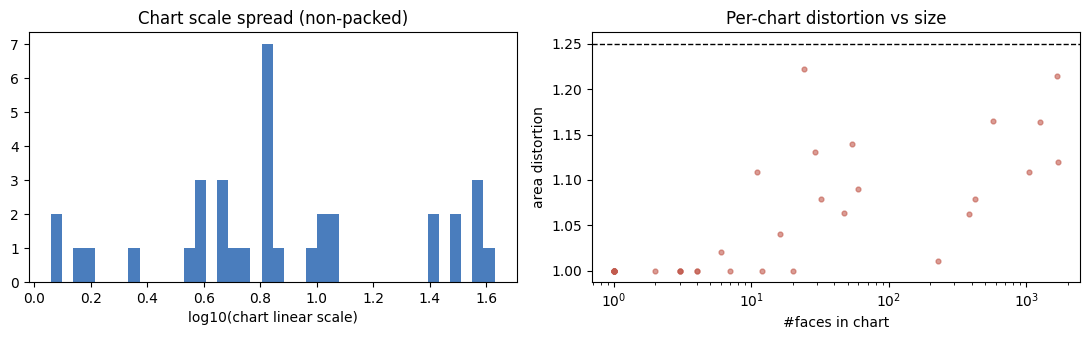

In [5]:
# ============ 未打包输出的 chart 尺度离散度(TD 不受控的实测证据) ============
s    = np.array([c["scale"]      for c in charts])
dist = np.array([c["distortion"] for c in charts])
nf   = np.array([len(c["F"])     for c in charts])

print(f"chart 线性尺度(每 chart 各自归一 unit square): min={s.min():.3g} max={s.max():.3g} "
      f"max/min={s.max()/max(s.min(),1e-12):.1f}x  CV={s.std()/s.mean():.2f}")
print(f"per-chart 面积失真: median={np.median(dist):.3f}  max={dist.max():.3f} "
      f"(τ={THRESHOLD}; 实测可能超界, 见 07 文档附录)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(np.log10(s), bins=40, color="#4a7dbd")
ax[0].set_xlabel("log10(chart linear scale)")
ax[0].set_title("Chart scale spread (non-packed)")
ax[1].scatter(nf, dist, s=12, alpha=0.6, color="#c25b4e")
ax[1].axhline(THRESHOLD, ls="--", c="k", lw=1)
ax[1].set_xscale("log")
ax[1].set_xlabel("#faces in chart"); ax[1].set_ylabel("area distortion")
ax[1].set_title("Per-chart distortion vs size")
plt.tight_layout(); plt.savefig(f"{OUT}/chart_stats.png", dpi=110); plt.show()

In [6]:
# ============ 密度层 mini-demo: L1 均匀 texel density ============
# 第 1 步: 重缩放每个 chart, 使 uv_area == 其 3D 表面积(uniform TD 定义)
# 第 2 步: 简易 shelf packing 放进同一图集(原型用; 正式版换 MaxRects / UVPackmaster)
PAD = 0.004

def shelf_pack(rects, pad=PAD):
    order = sorted(range(len(rects)), key=lambda i: -rects[i][1])   # 按高度降序
    W = max(np.sqrt(sum(w * h for w, h in rects)) * 1.15,
            max(w for w, _ in rects) + 2 * pad)
    x = y = row_h = 0.0
    pos = [None] * len(rects)
    for i in order:
        w, h = rects[i]
        if x + w + pad > W:
            x = 0.0; y += row_h + pad; row_h = 0.0
        pos[i] = (x + pad / 2, y + pad / 2)
        x += w + pad; row_h = max(row_h, h)
    side = max(W, y + row_h + pad)
    return [(px / side, py / side) for px, py in pos], side

uv_l1, rects = [], []
for c in charts:
    f = np.sqrt(c["a3"] / max(c["a2"], 1e-12))     # uv_area -> 3D area
    uv = c["UV"] * f
    uv = uv - uv.min(axis=0)
    uv_l1.append(uv)
    rects.append(tuple(uv.max(axis=0)))
offsets, side = shelf_pack(rects)
uv_l1 = [uv / side + np.array(off) for uv, off in zip(uv_l1, offsets)]
util = sum(w * h for w, h in rects) / side ** 2
print(f"L1 layout done: atlas side={side:.3g} (world units), bbox utilization≈{util:.2f}")

L1 layout done: atlas side=1.72 (world units), bbox utilization≈0.76


In [7]:
# ============ 打包升级: Blender pack_islands(保持相对密度尺度, 只管摆放) ============
# pack_islands 对全体 island 施加统一全局缩放 + 旋转/摆放 —— 不改变 chart 间相对大小,
# 因此我们的密度分配(L1/L2 的 sqrt(demand/a2) 缩放)原样保留; 失败时自动退回 shelf 结果。
def blender_repack(uv_list, margin=0.001):
    try:
        import bpy
    except Exception as e:
        print("bpy 不可用, 保留 shelf packing:", e); return None
    import tempfile, os as _os
    Vs, Fs, UVs, off = [], [], [], 0
    for c, uv in zip(charts, uv_list):
        cV = np.asarray(c["V"]); cF = np.asarray(c["F"])
        Vs.append(cV); UVs.append(uv); Fs.append(cF + off); off += len(cV)
    Vc, Fc, UVc = np.vstack(Vs), np.vstack(Fs), np.vstack(UVs)
    mm = trimesh.Trimesh(vertices=Vc, faces=Fc, process=False)
    mm.visual = trimesh.visual.TextureVisuals(uv=UVc)
    td_ = tempfile.mkdtemp(prefix="nbpack_")
    inp, outp = _os.path.join(td_, "in.obj"), _os.path.join(td_, "out.obj")
    mm.export(inp)
    if bpy.ops.object.mode_set.poll():
        bpy.ops.object.mode_set(mode="OBJECT")
    bpy.ops.object.select_all(action="SELECT"); bpy.ops.object.delete()
    bpy.ops.wm.obj_import(filepath=inp)
    bpy.ops.object.select_all(action="SELECT")
    bpy.ops.object.mode_set(mode="EDIT")
    bpy.ops.mesh.select_all(action="SELECT")
    bpy.ops.uv.select_all(action="SELECT")
    bpy.ops.uv.pack_islands(margin=margin)
    bpy.ops.object.mode_set(mode="OBJECT")
    bpy.ops.object.select_all(action="SELECT")
    bpy.ops.wm.obj_export(filepath=outp, export_selected_objects=True,
                          export_materials=False, export_normals=False)
    pm = trimesh.load(outp, process=False)
    if isinstance(pm, trimesh.Scene):
        pm = trimesh.util.concatenate(pm.dump())
    pV, pF, pUV = np.asarray(pm.vertices), np.asarray(pm.faces), np.asarray(pm.visual.uv)
    kd_p = cKDTree(pV[pF].mean(axis=1))
    ref = float(np.linalg.norm(Vc.max(0) - Vc.min(0)))
    out = []
    for c in charts:
        cV = np.asarray(c["V"]); cF = np.asarray(c["F"])
        d, pidx = kd_p.query(cV[cF].mean(axis=1))
        if (d > 1e-5 * ref).any():
            print("blender repack 对应失败, 保留 shelf"); return None
        new_uv = np.zeros((len(cV), 2))
        for i in range(len(cF)):
            PC = pV[pF[pidx[i]]]
            for k in range(3):
                j = int(np.argmin(((PC - cV[cF[i][k]]) ** 2).sum(1)))
                new_uv[cF[i][k]] = pUV[pF[pidx[i]][j]]
        out.append(new_uv)
    return out

def atlas_fill(uvs):
    return float(sum(tri_area_2d(uv[np.asarray(c["F"])]).sum()
                     for c, uv in zip(charts, uvs)))

_b = blender_repack(uv_l1)
if _b is not None:
    print(f"L1: shelf 有效纹素占比={atlas_fill(uv_l1):.2%} -> "
          f"Blender pack_islands={atlas_fill(_b):.2%}")
    uv_l1 = _b


Loaded image from: '/tmp/nbpack_fxep02qj/material_0.png'


L1: shelf 有效纹素占比=39.33% -> Blender pack_islands=63.08%


Writing to /tmp/nbpack_fxep02qj/out.obj


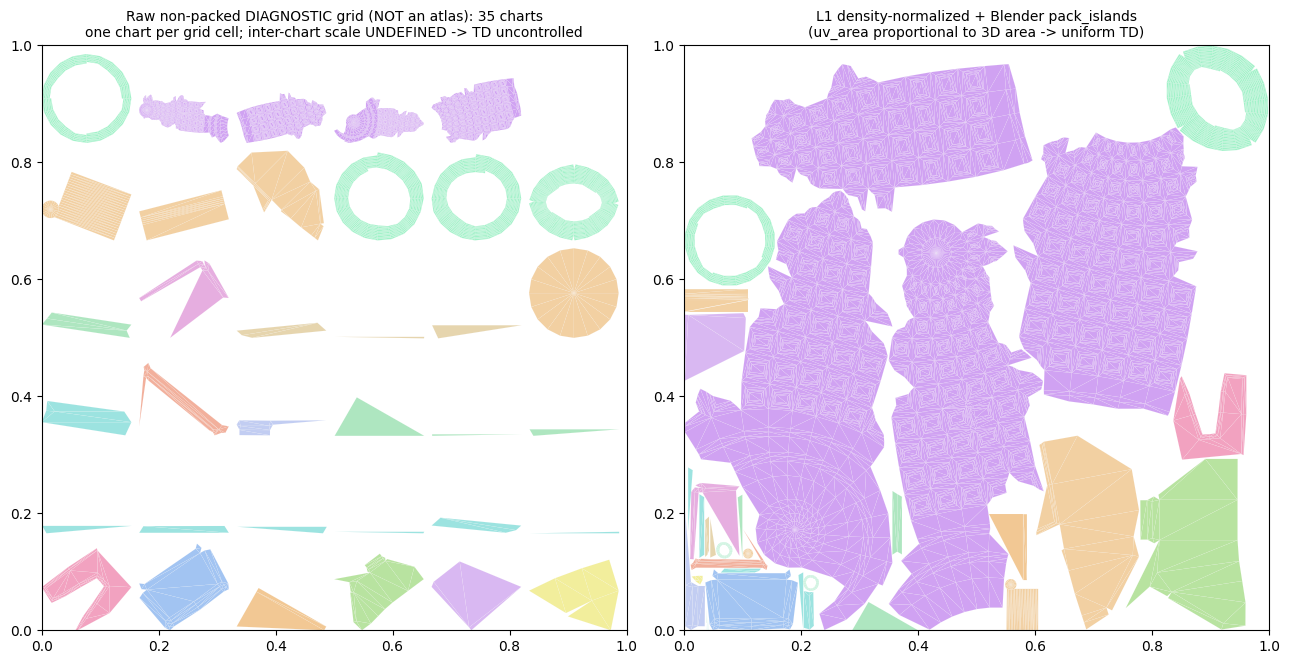

颜色 = 语义 part (PartUV 的 part 分组)


In [8]:
# ============ 布局可视化: raw(unit-square 网格摆放) vs L1 均匀密度 ============
from matplotlib.collections import PolyCollection
PALETTE = ["#f2a2c0", "#a2c4f2", "#f2c894", "#b8e3a0", "#d9b8f2", "#f2ee9c",
           "#9ce3e0", "#f2b09c", "#c2cdf2", "#aee6c0", "#e6aee0", "#e6d5ae",
           "#f2d0a2", "#a2f2c9", "#d0a2f2", "#c9f2a2", "#f2a2a2", "#a2d5f2"]

def draw_layout(ax, uvs, title):
    for c, uv in zip(charts, uvs):
        ax.add_collection(PolyCollection(uv[np.asarray(c["F"])],
                          facecolors=PALETTE[c["part"] % len(PALETTE)],
                          edgecolors="white", linewidths=0.05))
    ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)

K = len(charts); ncol = int(np.ceil(np.sqrt(K)))
uv_raw = []
for k, c in enumerate(charts):
    uv = c["UV"] - c["UV"].min(axis=0)
    cell = 1.0 / ncol
    uv_raw.append(uv / max(uv.max(), 1e-12) * cell * 0.92
                  + np.array([(k % ncol) * cell, (k // ncol) * cell]))

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5))
draw_layout(ax[0], uv_raw,
            f"Raw non-packed DIAGNOSTIC grid (NOT an atlas): {K} charts\none chart per grid cell; inter-chart scale UNDEFINED -> TD uncontrolled")
draw_layout(ax[1], uv_l1,
            "L1 density-normalized + Blender pack_islands\n(uv_area proportional to 3D area -> uniform TD)")
plt.tight_layout(); plt.savefig(f"{OUT}/layout_compare.png", dpi=110); plt.show()
print("颜色 = 语义 part (PartUV 的 part 分组)")

per-face TD CV(covered):        raw=1.780   L1=0.082
面积加权 TD CV(covered, 更贴近感知): raw=0.971   L1=0.076   (L1 残差 = chart 内失真, 由 τ 近似界住)


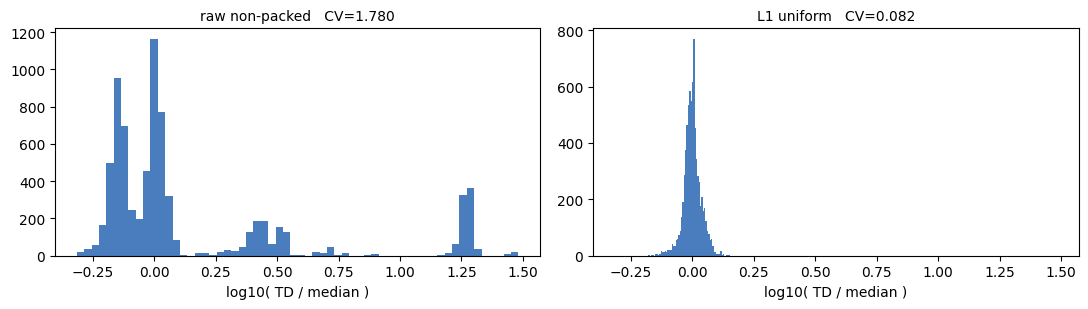

In [9]:
# ============ 逐面相对 TD 对比(核心指标) ============
def face_td(uvs):
    td = np.zeros(len(F))
    for c, uv in zip(charts, uvs):
        cF = np.asarray(c["F"])
        a2 = tri_area_2d(uv[cF])
        a3 = tri_area_3d(np.asarray(c["V"])[cF])
        td[c["gidx"]] = np.sqrt(a2 / np.maximum(a3, 1e-16))
    return td

cv = lambda x: float(x.std() / x.mean())
def cvw(td, w):                       # 面积加权 CV: 小三角形不再被过度加权, 更贴近感知
    m = np.average(td, weights=w)
    return float(np.sqrt(np.average((td - m) ** 2, weights=w)) / m)
td_raw, td_l1 = face_td(uv_raw), face_td(uv_l1)   # 丢弃面为 0, 统计时用 covered 排除
print(f"per-face TD CV(covered):        raw={cv(td_raw[covered]):.3f}   L1={cv(td_l1[covered]):.3f}")
print(f"面积加权 TD CV(covered, 更贴近感知): raw={cvw(td_raw[covered], a3_all[covered]):.3f}   "
      f"L1={cvw(td_l1[covered], a3_all[covered]):.3f}   (L1 残差 = chart 内失真, 由 τ 近似界住)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True)
for a, td, name in [(ax[0], td_raw, "raw non-packed"), (ax[1], td_l1, "L1 uniform")]:
    tdc = td[covered]
    a.hist(np.log10(tdc / np.median(tdc)), bins=60, color="#4a7dbd")
    a.set_title(f"{name}   CV={cv(tdc):.3f}", fontsize=10)
    a.set_xlabel("log10( TD / median )")
plt.tight_layout(); plt.savefig(f"{OUT}/td_hist.png", dpi=110); plt.show()

该网格没有原始 UV —— 只展示 re-UV 后的分布(before 面板跳过)
re-UV(L1) per-face TD: CV=0.082


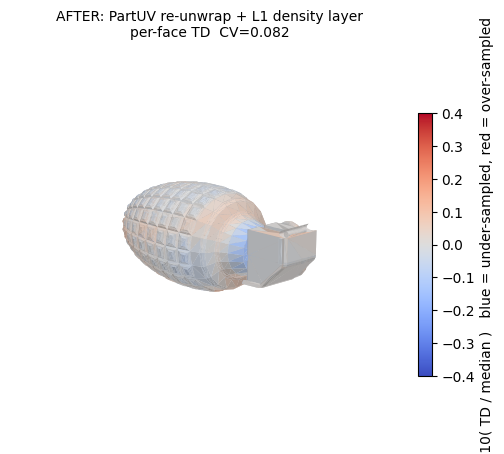

In [10]:
# ============ 纹理密度在物体表面上的体现: 原始 UV -> re-UV 后 (3D 热力图) ============
# 红 = TD 高(过采样) / 蓝 = TD 低(欠采样) / 白 = 中位数; 两图共用色标, 可直接对比
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.colors import Normalize

orig = trimesh.load(MESH, force="mesh")
uv0 = getattr(orig.visual, "uv", None)
Vo, Fo = np.asarray(orig.vertices, float), np.asarray(orig.faces)

td_before = None
if uv0 is not None:
    a2o = tri_area_2d(np.asarray(uv0, float)[Fo])
    a3o = tri_area_3d(Vo[Fo])
    td_before = np.sqrt(a2o / np.maximum(a3o, 1e-16))
    print(f"原始 UV per-face TD:  CV={cv(td_before):.3f}   面积加权 CV={cvw(td_before, a3o):.3f}"
          "   (两者差距大 = 不均匀主要来自微小三角形)")
else:
    print("该网格没有原始 UV —— 只展示 re-UV 后的分布(before 面板跳过)")
td_after = td_l1                       # L1 布局的逐面 TD(定义在 processed mesh 上)
print(f"re-UV(L1) per-face TD: CV={cv(td_after[covered]):.3f}"
      + (f"   (灰色={int((~covered).sum())} 个被管线丢弃的面)" if not covered.all() else ""))

VMAX = 0.4                             # 色标范围: log10(TD/median) ∈ [-0.4, 0.4] ≈ 0.4x~2.5x

def render_td_surface(ax, V_, F_, td, title, mask=None):
    tris = V_[F_]
    med = np.median(td if mask is None else td[mask])
    logr = np.clip(np.log10(np.maximum(td, 1e-12) / med), -VMAX, VMAX)
    col = plt.cm.coolwarm(logr / (2 * VMAX) + 0.5)
    if mask is not None and not mask.all():
        col[~mask] = (0.55, 0.55, 0.55, 1.0)      # 被管线丢弃的面: 灰色
    n = np.cross(tris[:, 1] - tris[:, 0], tris[:, 2] - tris[:, 0])
    n /= np.maximum(np.linalg.norm(n, axis=1, keepdims=True), 1e-12)
    shade = 0.65 + 0.35 * np.abs(n @ np.array([0.4, 0.5, 0.77]))   # 简易光照做形体提示
    col[:, :3] *= shade[:, None]
    ax.add_collection3d(Poly3DCollection(tris, facecolors=col, edgecolors="none"))
    mn, mx = V_.min(0), V_.max(0); c = (mn + mx) / 2; r = (mx - mn).max() / 2
    ax.set_xlim(c[0]-r, c[0]+r); ax.set_ylim(c[1]-r, c[1]+r); ax.set_zlim(c[2]-r, c[2]+r)
    ax.set_box_aspect((1, 1, 1)); ax.set_axis_off()
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=15, azim=45)

n_panel = 2 if td_before is not None else 1
fig = plt.figure(figsize=(6.2 * n_panel, 6.2))
if td_before is not None:
    render_td_surface(fig.add_subplot(1, n_panel, 1, projection="3d"), Vo, Fo, td_before,
                      f"BEFORE: original UV\nper-face TD  CV={cv(td_before):.3f}")
render_td_surface(fig.add_subplot(1, n_panel, n_panel, projection="3d"), V, F, td_after,
                  f"AFTER: PartUV re-unwrap + L1 density layer\nper-face TD  CV={cv(td_after[covered]):.3f}",
                  mask=covered)
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=Normalize(-VMAX, VMAX))
cb = fig.colorbar(sm, ax=fig.axes, shrink=0.55, pad=0.02)
cb.set_label("log10( TD / median )   blue = under-sampled, red = over-sampled")
plt.savefig(f"{OUT}/td_on_surface.png", dpi=110, bbox_inches="tight"); plt.show()

In [11]:
# ============ 纹理本身的改变: 原贴图 A -> rebake 进新布局得到贴图 B ============
# 串联α(rebake): 每个新纹素 -> 新UV反查3D点 -> 对应原面 -> 原UV -> 双线性采样贴图A。
# 物体外观应保持不变(信息量 B ≤ A, 见 03 文档); 变的是图集布局与像素预算分配。
texA = None
try:
    mat = orig.visual.material
    img = getattr(mat, "baseColorTexture", None) or getattr(mat, "image", None)
    if img is not None:
        texA = np.asarray(img.convert("RGB"), dtype=float) / 255.0
except Exception:
    pass

if texA is None or uv0 is None:
    print("该网格没有纹理或原始 UV —— 跳过 rebake 演示(demo OBJ 均无纹理)")
else:
    RES = 1024
    Ht, Wt = texA.shape[:2]

    def sample_bilinear(img, uv):
        x = np.clip(uv[:, 0], 0, 1) * (img.shape[1] - 1)
        y = np.clip(1 - uv[:, 1], 0, 1) * (img.shape[0] - 1)
        x0 = np.floor(x).astype(int); y0 = np.floor(y).astype(int)
        x1 = np.minimum(x0 + 1, img.shape[1] - 1); y1 = np.minimum(y0 + 1, img.shape[0] - 1)
        fx = (x - x0)[:, None]; fy = (y - y0)[:, None]
        return (img[y0, x0] * (1 - fx) * (1 - fy) + img[y0, x1] * fx * (1 - fy)
                + img[y1, x0] * (1 - fx) * fy + img[y1, x1] * fx * fy)

    # ⚠ preprocess() 会把 mesh 归一化(中心化+等比缩放), processed V 在归一化坐标系,
    # 而 trimesh.load 的原 mesh 在世界坐标系 —— 匹配前先做包围盒相似变换对齐
    co = (Vo.max(0) + Vo.min(0)) / 2
    cp = (V.max(0) + V.min(0)) / 2
    s_align = (np.linalg.norm(V.max(0) - V.min(0))
               / max(np.linalg.norm(Vo.max(0) - Vo.min(0)), 1e-12))
    Vo_al = (Vo - co) * s_align + cp

    # processed face -> original face(质心), 及原面角点/角序
    kd_o = cKDTree(Vo_al[Fo].mean(axis=1))
    d_o, f2o = kd_o.query(V[F].mean(axis=1))
    ok_map = d_o < 1e-4 * mesh_scale
    print(f"坐标系对齐: scale={s_align:.4g}; 面映射成功率={ok_map.mean():.2%} "
          f"(d_o max={d_o.max():.2e})")

    texB = np.zeros((RES, RES, 3)); filled = np.zeros((RES, RES), bool)
    skipped = 0
    for c, uvc in zip(charts, uv_l1):
        cF = np.asarray(c["F"]); cV = np.asarray(c["V"]); gidx = c["gidx"]
        for i in range(len(cF)):
            g = int(gidx[i])
            if not ok_map[g]:
                skipped += 1; continue
            og = int(f2o[g])
            uvP = uvc[cF[i]]
            P = np.stack([uvP[:, 0], 1 - uvP[:, 1]], 1) * RES   # 新UV角点->像素(图像约定: v=1 在顶行)
            C3 = cV[cF[i]]; O3 = Vo_al[Fo[og]]              # 两侧3D角点(已对齐坐标系, 角序可能不同)
            perm = [int(np.argmin(((O3 - C3[k]) ** 2).sum(1))) for k in range(3)]
            OUV = np.asarray(uv0, float)[Fo[og]][perm]      # 按新角序排列的原UV角点
            mn = np.maximum(np.floor(P.min(0)).astype(int), 0)
            mx = np.minimum(np.ceil(P.max(0)).astype(int), RES - 1)
            if (mx < mn).any():
                continue
            xs, ys = np.meshgrid(np.arange(mn[0], mx[0] + 1), np.arange(mn[1], mx[1] + 1))
            pts = np.stack([xs.ravel() + 0.5, ys.ravel() + 0.5], 1)
            T = np.stack([P[1] - P[0], P[2] - P[0]], 1)
            det = T[0, 0] * T[1, 1] - T[0, 1] * T[1, 0]
            if abs(det) < 1e-12:
                continue
            invT = np.array([[T[1, 1], -T[0, 1]], [-T[1, 0], T[0, 0]]]) / det
            w12 = (pts - P[0]) @ invT.T
            w0 = 1 - w12.sum(1)
            m = (w12[:, 0] >= -1e-4) & (w12[:, 1] >= -1e-4) & (w0 >= -1e-4)
            if not m.any():
                continue
            bary = np.stack([w0[m], w12[m, 0], w12[m, 1]], 1)
            uvo = bary @ OUV
            texB[ys.ravel()[m], xs.ravel()[m]] = sample_bilinear(texA, uvo)
            filled[ys.ravel()[m], xs.ravel()[m]] = True

    for _ in range(6):                                       # 简易 padding/dilation 防黑缝
        empty = ~filled
        acc = np.zeros_like(texB); cnt = np.zeros((RES, RES))
        for dx, dy in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
            sf = np.roll(filled, (dy, dx), (0, 1)); st = np.roll(texB, (dy, dx), (0, 1))
            w = (sf & empty).astype(float)
            acc += st * w[..., None]; cnt += w
        upd = cnt > 0
        texB[upd] = acc[upd] / cnt[upd][:, None]
        filled |= upd

    print(f"rebake 完成: {RES}x{RES}, 有效纹素占比={filled.mean():.2%}, 跳过映射失败面={skipped}")

    # ---- 图集对比: 贴图 A vs 贴图 B ----
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 6.2))
    ax[0].imshow(texA); ax[0].set_axis_off()
    ax[0].set_title(f"Texture A: original atlas ({Wt}x{Ht})", fontsize=10)
    ax[1].imshow(texB); ax[1].set_axis_off()
    ax[1].set_title(f"Texture B: rebaked into L1 density-uniform layout ({RES}x{RES})", fontsize=10)
    plt.tight_layout(); plt.savefig(f"{OUT}/texture_compare.png", dpi=110); plt.show()

    # ---- 带纹理 3D 预览: 逐面取贴图颜色, 外观应一致 ----
    colA = np.full((len(F), 3), 0.55)
    okA = ok_map
    centoUV = np.asarray(uv0, float)[Fo[f2o]].mean(axis=1)
    colA[okA] = sample_bilinear(texA, centoUV[okA])
    colB = np.full((len(F), 3), 0.55)
    for c, uvc in zip(charts, uv_l1):
        cF = np.asarray(c["F"]); g = c["gidx"]
        colB[g] = sample_bilinear(texB, uvc[cF].mean(axis=1))   # texB 已按图像约定写入

    def render_colored(axr, V_, F_, col, title):
        tris = V_[F_]
        n = np.cross(tris[:, 1] - tris[:, 0], tris[:, 2] - tris[:, 0])
        n /= np.maximum(np.linalg.norm(n, axis=1, keepdims=True), 1e-12)
        shade = (0.7 + 0.3 * np.abs(n @ np.array([0.4, 0.5, 0.77])))[:, None]
        axr.add_collection3d(Poly3DCollection(tris, facecolors=np.clip(col * shade, 0, 1),
                                              edgecolors="none"))
        mn, mx = V_.min(0), V_.max(0); ct = (mn + mx) / 2; r = (mx - mn).max() / 2
        axr.set_xlim(ct[0]-r, ct[0]+r); axr.set_ylim(ct[1]-r, ct[1]+r); axr.set_zlim(ct[2]-r, ct[2]+r)
        axr.set_box_aspect((1, 1, 1)); axr.set_axis_off(); axr.view_init(elev=15, azim=45)
        axr.set_title(title, fontsize=10)

    fig = plt.figure(figsize=(12.5, 6.2))
    render_colored(fig.add_subplot(1, 2, 1, projection="3d"), V, F, colA,
                   "textured with A (original UV)")
    render_colored(fig.add_subplot(1, 2, 2, projection="3d"), V, F, colB,
                   "textured with B (rebaked, L1 layout)\nappearance should match")
    plt.savefig(f"{OUT}/textured_render_compare.png", dpi=110, bbox_inches="tight"); plt.show()
    print("外观应基本一致 —— rebake 只搬运像素预算, 不改变内容(串联α); "
          "原本欠采样的区域 B 里也救不回来, 完整价值要靠串联β(重新生成), 见 07 文档 §1")


该网格没有纹理或原始 UV —— 跳过 rebake 演示(demo OBJ 均无纹理)


In [12]:
# ============ 保存指标 ============
metrics = dict(
    mesh=os.path.basename(MESH), n_faces=int(len(F)),
    n_parts=len(parts), n_charts=len(charts),
    time_preprocess_s=round(t1 - t0, 2), time_pipeline_s=round(t2 - t1, 2),
    centroid_coverage=float(covered.mean()),
    chart_scale_max_over_min=float(s.max() / max(s.min(), 1e-12)),
    chart_scale_cv=float(s.std() / s.mean()),
    distortion_median=float(np.median(dist)), distortion_max=float(dist.max()),
    td_cv_raw=cv(td_raw[covered]), td_cv_L1=cv(td_l1[covered]),
    td_cvw_raw=cvw(td_raw[covered], a3_all[covered]),
    td_cvw_L1=cvw(td_l1[covered], a3_all[covered]),
    n_dropped_faces=n_drop, dropped_area_share=round(drop_area_share, 5),
    td_cv_original_uv=(cv(td_before) if td_before is not None else None),
    td_cvw_original_uv=(cvw(td_before, a3o) if td_before is not None else None),
    l1_bbox_utilization=float(util),
    rebake_filled_ratio=(float(filled.mean()) if texA is not None and uv0 is not None else None),
)
with open(f"{OUT}/metrics.json", "w") as fp:
    json.dump(metrics, fp, indent=2, ensure_ascii=False)
print(json.dumps(metrics, indent=2, ensure_ascii=False))
print(f"\n输出目录: {OUT}")

{
  "mesh": "f45ac2100d2342fa8ab39d38d0f874ba.obj",
  "n_faces": 7618,
  "n_parts": 15,
  "n_charts": 35,
  "time_preprocess_s": 0.92,
  "time_pipeline_s": 3.37,
  "centroid_coverage": 1.0,
  "chart_scale_max_over_min": 37.24460382856897,
  "chart_scale_cv": 1.0130776298643482,
  "distortion_median": 1.0000000000000384,
  "distortion_max": 1.2218594190677552,
  "td_cv_raw": 1.779757768024931,
  "td_cv_L1": 0.08194011297841773,
  "td_cvw_raw": 0.9714296688955998,
  "td_cvw_L1": 0.07556663683475404,
  "n_dropped_faces": 0,
  "dropped_area_share": 0.0,
  "td_cv_original_uv": null,
  "td_cvw_original_uv": null,
  "l1_bbox_utilization": 0.7561436672967864,
  "rebake_filled_ratio": null
}

输出目录: /root/youjiaZhang/PartUV/code/notebook/outputs/f45ac2100d2342fa8ab39d38d0f874ba/


## L2 · 内容感知密度分配（研究增量的最小演示）

把布局的"相对大小"依据从 **纯 3D 面积**（官方隐式 L1）升级为 **3D 面积 × 内容权重**：
细节多的面（logo、螺栓、花纹）拿到更多纹素预算。内容权重这里用**原纹理做 oracle**
（每面 24 个重心采样点的亮度标准差）；生产中换成几何/语义先验或两遍法实测
（06 文档决策：不依赖 TDF）。`GAMMA=0` 退化为 L1。

In [13]:
# ============ L2: 内容感知密度分配 demand = a3 · (1+α·cw)^γ ============
GAMMA, ALPHA, W_CAP = 1.5, 3.0, 8.0
if texA is None or uv0 is None:
    print("无纹理 -> 跳过 L2 演示(需要带纹理的 glb)")
else:
    # ---- 1. per-face 内容权重 cw: 面内 24 个重心采样点的亮度 std(oracle) ----
    rng = np.random.RandomState(0)
    bar = rng.dirichlet((1.2, 1.2, 1.2), 24)                    # (24,3) 重心坐标
    lum = texA @ np.array([0.299, 0.587, 0.114])
    OUV3 = np.asarray(uv0, float)[Fo[f2o]]                      # (nF,3,2) 对应原面的 UV 角点
    cw = np.zeros(len(F))
    samp = np.einsum("sk,fkd->sfd", bar, OUV3)                  # (24,nF,2)
    for s in range(len(bar)):
        x = np.clip(samp[s, :, 0], 0, 1) * (lum.shape[1] - 1)
        y = np.clip(1 - samp[s, :, 1], 0, 1) * (lum.shape[0] - 1)
        vals = lum[y.astype(int), x.astype(int)]
        if s == 0:
            acc, acc2 = vals.copy(), vals ** 2
        else:
            acc += vals; acc2 += vals ** 2
    cw = np.sqrt(np.maximum(acc2 / len(bar) - (acc / len(bar)) ** 2, 0))
    cw[~ok_map] = 0
    cw_n = cw / max(np.median(cw[covered & ok_map]) , 1e-9)     # 以中位数归一
    w = np.clip((1 + ALPHA * cw_n) ** GAMMA, 1, W_CAP)          # 每面的预算倍率

    # ---- 2. per-chart demand -> 缩放 -> 重打包 ----
    uv_l2, rects2 = [], []
    for c in charts:
        cF = np.asarray(c["F"]); g = c["gidx"]
        a3f = tri_area_3d(np.asarray(c["V"])[cF])
        demand = float((a3f * w[g]).sum())
        f = np.sqrt(demand / max(c["a2"], 1e-12))
        uv = c["UV"] * f; uv = uv - uv.min(axis=0)
        uv_l2.append(uv); rects2.append(tuple(uv.max(axis=0)))
    off2, side2 = shelf_pack(rects2)
    uv_l2 = [uv / side2 + np.array(o) for uv, o in zip(uv_l2, off2)]
    util2 = sum(wd * h for wd, h in rects2) / side2 ** 2
    if 'blender_repack' in globals():
        _b2 = blender_repack(uv_l2)
        if _b2 is not None:
            uv_l2 = _b2; util2 = atlas_fill(uv_l2)

    # ---- 3. 指标: L2 是否把预算按内容分对了 ----
    td_l2 = face_td(uv_l2)
    cov_ok = covered & ok_map
    hi = cov_ok & (cw_n >= np.quantile(cw_n[cov_ok], 0.9))      # 内容 top-10% 的面
    lo = cov_ok & (cw_n <= np.quantile(cw_n[cov_ok], 0.5))
    gain_hi = float(np.average(td_l2[hi], weights=a3_all[hi])
                    / np.average(td_l1[hi], weights=a3_all[hi]))
    gain_lo = float(np.average(td_l2[lo], weights=a3_all[lo])
                    / np.average(td_l1[lo], weights=a3_all[lo]))
    corr = float(np.corrcoef(np.log(np.maximum(td_l2[cov_ok], 1e-12) ** 2),
                             np.log(w[cov_ok]))[0, 1])
    print(f"L2 layout: γ={GAMMA} α={ALPHA}  bbox util={util2:.2f} (L1={util:.2f})")
    print(f"内容 top-10% 面的 TD 增益(L2/L1): ×{gain_hi:.2f}   低内容面: ×{gain_lo:.2f}")
    print(f"corr( log TD², log 目标权重 ) = {corr:.3f}  (→1 表示预算按需分配)")

    # ---- 4. 布局对比图: 按内容权重着色 ----
    from matplotlib.collections import PolyCollection
    from matplotlib.colors import Normalize
    cn = Normalize(0, np.quantile(cw_n[cov_ok], 0.98))
    fig, axs = plt.subplots(1, 2, figsize=(13, 6.5))
    for axp, uvs, name_ in [(axs[0], uv_l1, f"L1 uniform (area-proportional)"),
                            (axs[1], uv_l2, f"L2 content-aware (γ={GAMMA})")]:
        for c, uv in zip(charts, uvs):
            cF = np.asarray(c["F"])
            axp.add_collection(PolyCollection(
                uv[cF], facecolors=plt.cm.plasma(cn(cw_n[c["gidx"]])), edgecolors="none"))
        axp.set_aspect("equal"); axp.set_xlim(0, 1); axp.set_ylim(0, 1)
        axp.set_title(name_ + "\ncolor = content weight (plasma)", fontsize=10)
    sm = plt.cm.ScalarMappable(cmap="plasma", norm=cn)
    fig.colorbar(sm, ax=axs, shrink=0.6).set_label("content weight cw_n")
    plt.savefig(f"{OUT}/layout_L1_vs_L2.png", dpi=110, bbox_inches="tight"); plt.show()

    # ---- 5. rebake 到两种布局, 高内容 chart 的图集裁剪对比 ----
    def rebake_into(uv_layout, res=1024):
        tex = np.zeros((res, res, 3)); fil = np.zeros((res, res), bool)
        for c, uvc in zip(charts, uv_layout):
            cF = np.asarray(c["F"]); cV = np.asarray(c["V"]); gidx = c["gidx"]
            for i in range(len(cF)):
                g = int(gidx[i])
                if not ok_map[g]:
                    continue
                og = int(f2o[g]); uvP = uvc[cF[i]]
                P = np.stack([uvP[:, 0], 1 - uvP[:, 1]], 1) * res
                C3 = cV[cF[i]]; O3 = Vo_al[Fo[og]]
                perm = [int(np.argmin(((O3 - C3[k]) ** 2).sum(1))) for k in range(3)]
                OUVp = np.asarray(uv0, float)[Fo[og]][perm]
                mn = np.maximum(np.floor(P.min(0)).astype(int), 0)
                mx = np.minimum(np.ceil(P.max(0)).astype(int), res - 1)
                if (mx < mn).any():
                    continue
                xs, ys = np.meshgrid(np.arange(mn[0], mx[0] + 1), np.arange(mn[1], mx[1] + 1))
                pts = np.stack([xs.ravel() + 0.5, ys.ravel() + 0.5], 1)
                T = np.stack([P[1] - P[0], P[2] - P[0]], 1)
                det = T[0, 0] * T[1, 1] - T[0, 1] * T[1, 0]
                if abs(det) < 1e-12:
                    continue
                invT = np.array([[T[1, 1], -T[0, 1]], [-T[1, 0], T[0, 0]]]) / det
                w12 = (pts - P[0]) @ invT.T; w0 = 1 - w12.sum(1)
                m = (w12[:, 0] >= -1e-4) & (w12[:, 1] >= -1e-4) & (w0 >= -1e-4)
                if not m.any():
                    continue
                bry = np.stack([w0[m], w12[m, 0], w12[m, 1]], 1)
                tex[ys.ravel()[m], xs.ravel()[m]] = sample_bilinear(texA, bry @ OUVp)
                fil[ys.ravel()[m], xs.ravel()[m]] = True
        return tex, fil

    texL1, filL1 = rebake_into(uv_l1)
    texL2, filL2 = rebake_into(uv_l2)

    # 最高内容 chart 的裁剪: 同一表面区域在两个 1024 图集里各占多少像素
    mean_cw = [float(np.average(cw_n[c["gidx"]], weights=a3_all[c["gidx"]])) for c in charts]
    big = [i for i, c in enumerate(charts) if len(c["F"]) >= 100]      # 只在实质 chart 里选
    k = max(big, key=lambda i: mean_cw[i]) if big else int(np.argmax(mean_cw))
    def crop(tex, uvs, res=1024):
        uv = uvs[k]
        mn = np.maximum((np.array([uv[:, 0].min(), 1 - uv[:, 1].max()]) * res).astype(int) - 2, 0)
        mx = np.minimum((np.array([uv[:, 0].max(), 1 - uv[:, 1].min()]) * res).astype(int) + 2, res)
        return tex[mn[1]:mx[1], mn[0]:mx[0]]
    c1, c2 = crop(texL1, uv_l1), crop(texL2, uv_l2)
    fig, axs = plt.subplots(1, 2, figsize=(11, 5.6))
    axs[0].imshow(c1); axs[0].set_title(f"L1: highest-content chart = {c1.shape[1]}x{c1.shape[0]} px", fontsize=10)
    axs[1].imshow(c2); axs[1].set_title(f"L2: same chart = {c2.shape[1]}x{c2.shape[0]} px (same 1024 atlas)", fontsize=10)
    for a in axs: a.set_axis_off()
    plt.tight_layout(); plt.savefig(f"{OUT}/crop_L1_vs_L2.png", dpi=110); plt.show()

    json.dump(dict(gamma=GAMMA, alpha=ALPHA, util_L1=float(util), util_L2=float(util2),
                   gain_top10_content=gain_hi, gain_low_content=gain_lo,
                   corr_logTD2_logW=corr),
              open(f"{OUT}/l2_metrics.json", "w"), indent=2)
    print("同一张 1024 图集: 高内容 chart 在 L2 里拿到的像素 ≈ L1 的 "
          f"{(c2.shape[0]*c2.shape[1])/max(c1.shape[0]*c1.shape[1],1):.2f} 倍")


无纹理 -> 跳过 L2 演示(需要带纹理的 glb)


## 怎么读结果

- **td_on_surface.png（3D 热力图）**：最直观的一张——BEFORE 是物体原始 UV 的
  纹理密度分布（颜色越花 = 忽高忽低），AFTER 是 re-UV-map 后的分布
  （接近全白 = 均匀，残余色差来自 chart 内参数化失真，由 τ 近似界住）；
- **chart scale spread / td_cv_raw**：未打包输出的 chart 间尺度完全未定
  （README 原话 *inter-chart arrangement is not yet solved*）——这就是密度层要接管的自由度；
- **td_cv_L1**：只做"按 3D 面积重缩放 + 重打包"就能把 per-face TD 变异压到 chart 内失真的量级
  （残差由 τ 近似界住，实测个别 chart 会超 τ，见 `纹理密度/07-原型验证方案.md` 附录）；
- **l1_bbox_utilization**：shelf packing 只是原型；正式版换 MaxRects（`纹理密度/tdopt/pack2.py`）
  或 UVPackmaster 后利用率会明显更高。

## 下一步（对应 04 文档档 A → B）

1. **L2 内容感知**：对带纹理的 glb（data 里有两个 objaverse），用原纹理算 per-face
   content weight（`纹理密度/tdopt/content_weight.py`），demand = a3 · cw^γ，
   per-part 缩放替换本 notebook 的"纯 3D 面积"缩放；
2. **rebake 验证**：新旧 UV 之间重烘焙纹理（`tdopt/rebake_texture.py`），4K oracle →
   1K 新/旧布局对比清晰度；
3. **打包升级**：MaxRects + per-part 分组约束，报告 packing efficiency。